In [26]:
import matplotlib.pyplot as plt
from matplotlib.collections import PolyCollection
import numpy as np

def naca_4digit(string : str, n : int, alpha : float = 0, position_of_center : np.ndarray = np.array([0.5,0])) -> np.ndarray:
    """
    Returns the airfoil camber line and thickness distribution.
    Parameters
    ----------
    string : str
        A string consisting of 4 integers like "0012". This is the "name" of the airfoil
    n : int
        The number of points you want to modulate the airfoil with
    """

    # Raise error if name of NACA-airfoil is not 4 long
    if len(string) != 4:
        raise IndexError("The string needs to have the length 4")
    
    # Fetch information from the name of the airfoil
    m = int(string[0])/100
    p = int(string[1])/10 if string[1] != "0" else 0.1
    t = int(string[2] + string[3])/100

    # If an equal amount of nodes is used to approximate the airfoil
    if (n//2)*2 == n:

        # Create a linspace with points spaced equally between 0 and pi for the upper and lower surface of the airfoil
        beta = np.linspace(0,np.pi,(n//2)+1)

        # Convert this linspace to an array with points that are the most concentrated at the edges of the airfoil.
        x = (1-np.cos(beta))/2

        # Define the thickness of the airfoil distrebution in terms of x
        yt = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1036 * x**4)

        # Define the camber in terms of x
        yc = np.where(x < p, m/p**2 * (2*p*x - x**2), m/(1-p)**2 * ((1-2*p) + 2*p*x - x**2))

        # Create the lower and upper part of the airfoil
        lower = np.hstack((x.reshape(-1,1), (yc - yt).reshape(-1,1)))[::-1][:-1]
        upper = np.hstack((x.reshape(-1,1), (yc + yt).reshape(-1,1)))[:-1]

    # If an odd amount of nodes is used to approximate the airfoil
    elif (n//2)*2 != n:

        # Create a linspace with points spaced equally between 0 and pi for the lower surface of the airfoil with one more point than for the upper part
        beta = np.linspace(0,np.pi,(n//2)+1)

        # Convert this linspace to an array with points that are the most concentrated at the edges of the airfoil.
        x = (1-np.cos(beta))/2
        
        # Define the thickness of the airfoil distrebution in terms of x
        yt = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1036 * x**4)

        # Define the camber in terms of x
        yc = np.where(x < p, m/p**2 * (2*p*x - x**2), m/(1-p)**2 * ((1-2*p) + 2*p*x - x**2))

        # Define the lower part of the airfoil
        lower = np.hstack((x.reshape(-1,1), (yc - yt).reshape(-1,1)))[::-1][:-1]

        # Create a linspace with points spaced equally between 0 and pi for the upper surface of the airfoil
        beta = np.linspace(0,np.pi,(n//2)+2)

        # Convert this linspace to an array with points that are the most concentrated at the edges of the airfoil.
        x = (1-np.cos(beta))/2
        
        # Define the thickness of the airfoil distrebution in terms of x
        yt = 5 * t * (0.2969 * np.sqrt(x) - 0.1260 * x - 0.3516 * x**2 + 0.2843 * x**3 - 0.1036 * x**4)

        # Define the camber in terms of x
        yc = np.where(x < p, m/p**2 * (2*p*x - x**2), m/(1-p)**2 * ((1-2*p) + 2*p*x - x**2))

        # Define the upper part of the airfoil
        upper = np.hstack((x.reshape(-1,1), (yc + yt).reshape(-1,1)))[:-1]
    
    # Stack the points of the lower surface on top of the points from the upper surface
    points = np.vstack((lower, upper))

    # Relocate the airfoil such that it haves its center at the origin
    points -= np.array([0.5,0])

    # Rotate the airfoil
    alpha = np.deg2rad(alpha)
    rot_matrix = np.array([[np.cos(alpha), -np.sin(alpha)], [np.sin(alpha), np.cos(alpha)]])
    points = np.dot(points, rot_matrix)

    # Relocate the airfoil such that it haves its center as desired
    points += position_of_center

    # Return points defining the airfoil
    return points

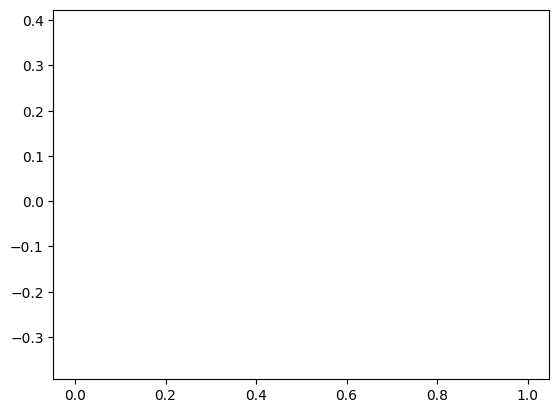

In [ ]:
fig, ax = plt.subplots()

ax.set_xlim(-5,5)
ax.set_ylim(-1,1)
pc = PolyCollection(naca_4digit("0012", 200, alpha=5).reshape(200,1,2), edgecolor="black", facecolor="lightblue", alpha=0.5)

plt.scatter
ax.add_collection(pc)
plt.axis("equal")
plt.show()